In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.4 MB/s eta 0:00:00


In [5]:
!pip install roboflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 110.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.90
    Uninstalling opencv-python-headless-4.13.0.90:
      Successfully uninstalled opencv-python-headless-4.13.0.90
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="P3FPqjdT3M8cUVClBV2n")
project = rf.workspace("dao-minh-uyi1j").project("445-kkjfi")
version = project.version(5)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...
Exporting format yolo26 in progress : 85.0%
Version export complete for yolo26 format



Extracting Dataset Version Zip to 445-5 in yolo26:: 100%|██████████| 1106/1106 [00:00<00:00, 1958.34it/s]


In [2]:
!rm -rf /content/445-4

In [5]:
import os
import random
import shutil

# Correct paths based on your image
root_path = '/content/445-5'
train_img_path = '/content/445-5/train/images'
train_lbl_path = '/content/445-5/train/labels'

# Create validation folders
os.makedirs('/content/445-5/valid/images', exist_ok=True)
os.makedirs('/content/445-5/valid/labels', exist_ok=True)

# Get all images
images = [f for f in os.listdir(train_img_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
random.shuffle(images)

# Calculate 20% for validation
val_count = int(len(images) * 0.2)
val_files = images[:val_count]

for filename in val_files:
    # Move image
    shutil.move(os.path.join(train_img_path, filename),
                os.path.join('/content/445-5/valid/images', filename))

    # Move label (same name but .txt)
    label_file = os.path.splitext(filename)[0] + '.txt'
    label_src = os.path.join(train_lbl_path, label_file)
    if os.path.exists(label_src):
        shutil.move(label_src, os.path.join('/content/445-5/valid/labels', label_file))

print(f"Done! Moved {val_count} images to /content/445-5/valid")

Done! Moved 110 images to /content/445-5/valid


In [6]:
import cv2
import os
from tqdm import tqdm

def resize_images_in_folder(folder_path, target_size=(640, 640)):
    if not os.path.exists(folder_path):
        print(f"Folder {folder_path} not found. Skipping...")
        return

    print(f"Resizing images in: {folder_path}")

    # Get list of images
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for filename in tqdm(files):
        img_path = os.path.join(folder_path, filename)

        # Read image
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Resize image
        # Note: This will stretch/squash the image to exactly 640x640
        # This matches how YOLO processes them internally.
        resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)

        # Overwrite the original image
        cv2.imwrite(img_path, resized_img)

# Paths based on your setup
folders_to_resize = [
    '/content/445-5/train/images',
    '/content/445-5/valid/images' # Assuming you ran the split script from the previous step
]

for folder in folders_to_resize:
    resize_images_in_folder(folder, target_size=(640, 640))

print("All images resized. Bounding box labels remain valid because they are normalized!")

Resizing images in: /content/445-5/train/images


100%|██████████| 440/440 [00:06<00:00, 69.98it/s]


Resizing images in: /content/445-5/valid/images


100%|██████████| 110/110 [00:01<00:00, 95.97it/s]

All images resized. Bounding box labels remain valid because they are normalized!


In [7]:
!pip install -U albumentations

In [8]:
import albumentations as A
import cv2
import os
import numpy as np
from tqdm import tqdm

# --- CONFIGURATION ---
INPUT_IMG_DIR = '/content/445-5/train/images'
INPUT_LBL_DIR = '/content/445-5/train/labels'
N_AUG_PER_IMAGE = 3

# Updated Pipeline (Fixed for latest Albumentations versions)
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # ShiftScaleRotate updated to avoid warnings, though it still works fine
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5, border_mode=cv2.BORDER_CONSTANT),
    A.Perspective(scale=(0.05, 0.1), p=0.3),
    A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Blur(blur_limit=3, p=0.2),
    # Fixed GaussNoise parameter for newer versions
    A.GaussNoise(mean=0, var_limit=(10.0, 50.0), p=0.2),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))

def augment_data(img_dir, lbl_dir, n_aug):
    image_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    # Filter out previously augmented images so we don't augment the augmentations
    image_files = [f for f in image_files if "_aug_" not in f]

    print(f"Starting augmentation... Processing {len(image_files)} original images.")

    for filename in tqdm(image_files):
        img_path = os.path.join(img_dir, filename)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(filename)[0] + ".txt")

        if not os.path.exists(lbl_path):
            continue

        image = cv2.imread(img_path)
        if image is None: continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        bboxes = []
        class_labels = []

        # Load and Clean Labels
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) < 5: continue # Skip broken lines

                cls = int(float(parts[0]))
                # Ensure exactly 4 coordinates and clip them between 0 and 1
                coords = [max(0.0, min(1.0, float(x))) for x in parts[1:5]]

                # Check for zero width or height (prevents errors)
                if coords[2] > 0 and coords[3] > 0:
                    bboxes.append(coords)
                    class_labels.append(cls)

        if not bboxes: continue # Skip images with no valid bboxes

        # Generate N augmented versions
        for i in range(n_aug):
            try:
                augmented = transform(image=image, bboxes=bboxes, class_labels=class_labels)
                aug_img = augmented['image']
                aug_bboxes = augmented['bboxes']
                aug_cls = augmented['class_labels']

                if len(aug_bboxes) == 0: continue

                new_name = f"{os.path.splitext(filename)[0]}_aug_{i}"

                # Save Image
                cv2.imwrite(os.path.join(img_dir, f"{new_name}.jpg"), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

                # Save Label
                with open(os.path.join(lbl_dir, f"{new_name}.txt"), 'w') as f:
                    for idx, bbox in enumerate(aug_bboxes):
                        f.write(f"{aug_cls[idx]} {' '.join([f'{x:.6f}' for x in bbox])}\n")
            except Exception as e:
                # This catches any remaining inhomogeneous shape issues
                print(f"Skipping {filename} due to error: {e}")
                continue

# Run it
augment_data(INPUT_IMG_DIR, INPUT_LBL_DIR, N_AUG_PER_IMAGE)
print("Augmentation Complete!")

ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
Argument(s) 'mean, var_limit' are not valid for transform GaussNoise


Starting augmentation... Processing 440 original images.


100%|██████████| 440/440 [00:20<00:00, 21.56it/s]

Augmentation Complete!


/content/445-5/train/labels/image_1168_idx1200_webp.rf.ee8f2f2397e29b32c5dc89d892cf696d_aug_2.txt


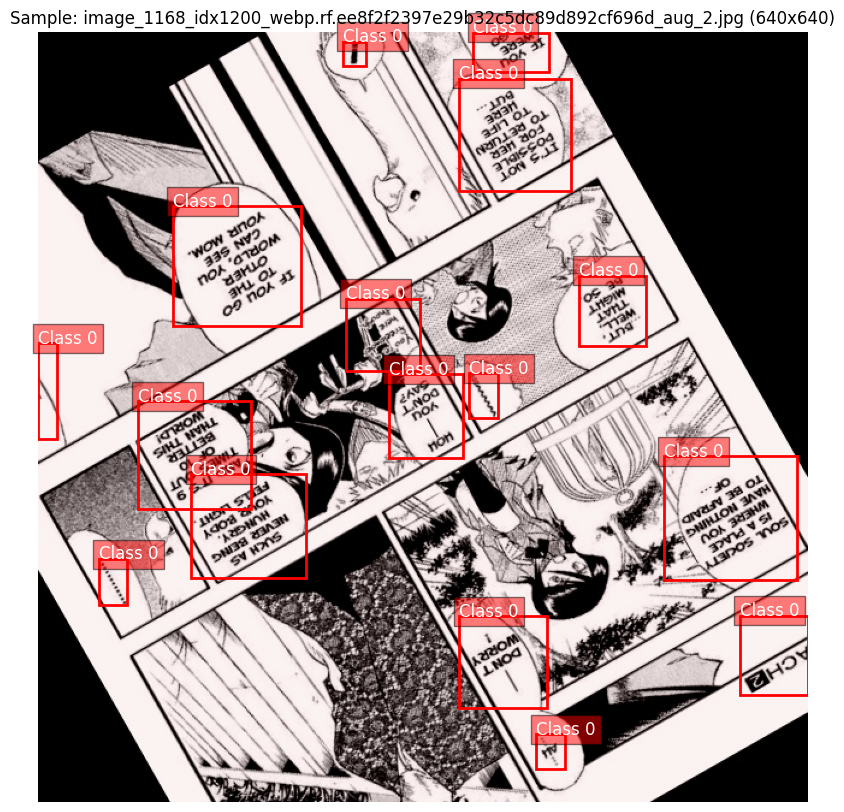

In [12]:
import cv2
import matplotlib.pyplot as plt
import os
import random

def visualize_random_sample(img_dir, lbl_dir):
    # Get list of images
    image_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not image_files:
        print("No images found!")
        return

    # Pick a random image
    random_image = random.choice(image_files)
    img_path = os.path.join(img_dir, random_image)
    lbl_path = os.path.join(lbl_dir, os.path.splitext(random_image)[0] + ".txt")
    print(lbl_path)
    # Load image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    ax = plt.gca()

    # Load and draw labels
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                # YOLO format: class_id x_center y_center width height
                cls, x_c, y_c, box_w, box_h = map(float, line.split())

                # Denormalize coordinates (convert 0-1 back to pixel values)
                x1 = (x_c - box_w / 2) * w
                y1 = (y_c - box_h / 2) * h
                width_px = box_w * w
                height_px = box_h * h

                # Create Rectangle patch
                rect = plt.Rectangle((x1, y1), width_px, height_px, fill=False, color='red', linewidth=2)
                ax.add_patch(rect)
                ax.text(x1, y1, f"Class {int(cls)}", color='white', fontsize=12, bbox=dict(facecolor='red', alpha=0.5))
    else:
        print(f"No label found for {random_image}")

    plt.title(f"Sample: {random_image} ({w}x{h})")
    plt.axis('off')
    plt.show()

# Execute visualization
visualize_random_sample(
    img_dir='/content/445-5/train/images',
    lbl_dir='/content/445-5/train/labels'
)


In [25]:
from ultralytics import YOLO
model = YOLO('/content/runs/detect/train3/weights/best.pt')

In [20]:
# for i, (name, param) in enumerate(model.named_parameters()):
#     print(f"Layer {i}: {name}")

# # Example: Freeze only layers with "model.0" through "model.9" in the name
# freeze_list = [f"model.{i}." for i in range(15)]

# for name, param in model.named_parameters():
#     if any(x in name for x in freeze_list):
#         param.requires_grad = False
#         print(f"Freezing {name}")

Layer 0: model.model.0.conv.weight
Layer 1: model.model.0.bn.weight
Layer 2: model.model.0.bn.bias
Layer 3: model.model.1.conv.weight
Layer 4: model.model.1.bn.weight
Layer 5: model.model.1.bn.bias
Layer 6: model.model.2.cv1.conv.weight
Layer 7: model.model.2.cv1.bn.weight
Layer 8: model.model.2.cv1.bn.bias
Layer 9: model.model.2.cv2.conv.weight
Layer 10: model.model.2.cv2.bn.weight
Layer 11: model.model.2.cv2.bn.bias
Layer 12: model.model.2.m.0.cv1.conv.weight
Layer 13: model.model.2.m.0.cv1.bn.weight
Layer 14: model.model.2.m.0.cv1.bn.bias
Layer 15: model.model.2.m.0.cv2.conv.weight
Layer 16: model.model.2.m.0.cv2.bn.weight
Layer 17: model.model.2.m.0.cv2.bn.bias
Layer 18: model.model.3.conv.weight
Layer 19: model.model.3.bn.weight
Layer 20: model.model.3.bn.bias
Layer 21: model.model.4.cv1.conv.weight
Layer 22: model.model.4.cv1.bn.weight
Layer 23: model.model.4.cv1.bn.bias
Layer 24: model.model.4.cv2.conv.weight
Layer 25: model.model.4.cv2.bn.weight
Layer 26: model.model.4.cv2.bn.b

In [ ]:
model.train(data="/content/445-5/data.yaml", epochs=50, imgsz=640, dropout=0.1)


Ultralytics 8.4.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/445-5/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train3/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

In [24]:
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_runnin

In [23]:
model.train()

KeyError: 'model'